   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookcases   
1        Furniture  

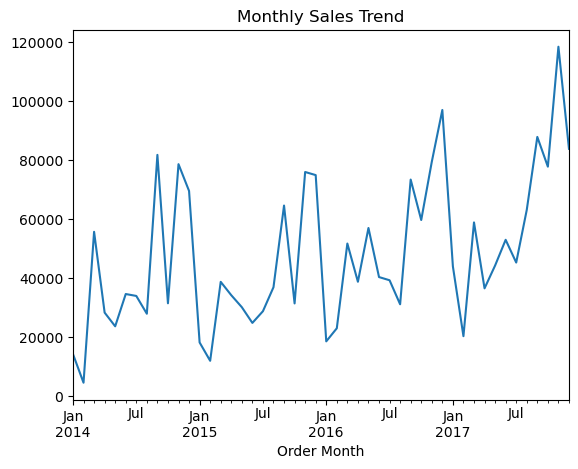

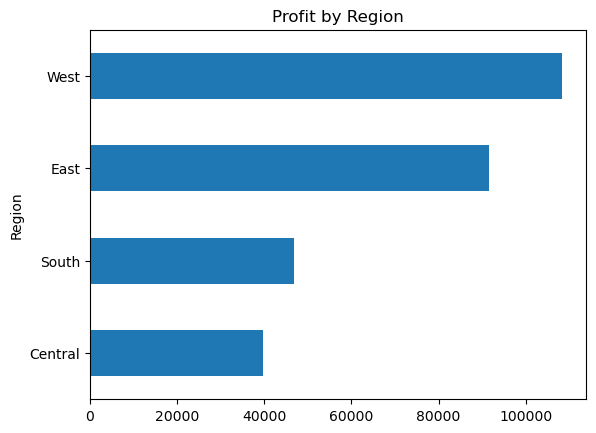

In [23]:
import pandas as pd

df = pd.read_csv("Data-Superstore.csv", encoding="latin1")
print(df.head())

# Check nulls and duplicates
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create helper columns
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year'] = df['Order Date'].dt.year
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

df.to_csv("Data-Superstore.csv", index=False)

import matplotlib.pyplot as plt

monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales.plot(kind='line', title='Monthly Sales Trend')
plt.show()

region_profit = df.groupby('Region')['Profit'].sum().sort_values()
region_profit.plot(kind='barh', title='Profit by Region')
plt.show()

